In [1]:
# ============================================================
# WEEK 2 — Contextual Data Fusion & Feature Engineering
# Project: Contextual Predictive Maintenance
# Intern Branch: preeti-dev
# Infotact Solutions
# ============================================================
 
 
# ── CELL 1: Install & Import Libraries ───────────────────
import subprocess, sys
 
def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
 
for lib in ["pandas", "numpy", "matplotlib", "seaborn", "scikit-learn"]:
    install(lib)
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
 
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
 
print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [2]:
# ── CELL 2: Load Week 1 Processed Data ───────────────────
# We continue from where Week 1 left off
df = pd.read_csv('../data/processed/week1_features.csv')
 
print(f"✅ Week 1 data loaded successfully")
print(f"   Rows    : {df.shape[0]}")
print(f"   Columns : {df.shape[1]}")
df.head()

✅ Week 1 data loaded successfully
   Rows    : 10000
   Columns : 29


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,...,Process_temperature_K_roll_var,Rotational_speed_rpm_roll_mean,Rotational_speed_rpm_roll_std,Rotational_speed_rpm_roll_var,Torque_Nm_roll_mean,Torque_Nm_roll_std,Torque_Nm_roll_var,Tool_wear_min_roll_mean,Tool_wear_min_roll_std,Tool_wear_min_roll_var
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,...,0.000000,1551.000000,0.000000,0.000000,42.800000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,...,0.005000,1479.500000,101.116270,10224.500000,44.550000,2.474874,6.125000,1.500000,2.121320,4.500000
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,...,0.010000,1485.666667,72.293384,5226.333333,46.166667,3.302020,10.903333,2.666667,2.516611,6.333333
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,...,0.006667,1472.500000,64.634872,4177.666667,44.500000,4.287190,18.380000,3.750000,2.986079,8.916667
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,...,0.007000,1459.600000,62.970628,3965.300000,43.600000,4.223150,17.835000,4.800000,3.492850,12.200000


In [3]:
# ── CELL 3: Simulate Timestamps ──────────────────────────
# The original dataset has no real timestamps.
# We simulate one reading every 10 minutes, starting from a fixed date.
# This lets us merge external data "based on precise timestamps"
# exactly as the project spec requires.
 
start_time = pd.Timestamp('2024-01-01 00:00:00')
df['timestamp'] = pd.date_range(start=start_time, periods=len(df), freq='10min')
 
print("✅ Timestamps simulated")
print(df[['timestamp']].head())
print(f"\nDate range: {df['timestamp'].min()}  →  {df['timestamp'].max()}")

✅ Timestamps simulated
            timestamp
0 2024-01-01 00:00:00
1 2024-01-01 00:10:00
2 2024-01-01 00:20:00
3 2024-01-01 00:30:00
4 2024-01-01 00:40:00

Date range: 2024-01-01 00:00:00  →  2024-03-10 10:30:00


In [4]:
# ── CELL 4: Simulate External Context Data ───────────────
# This represents what would normally come from a weather API
# or a factory load sensor (V2X / IoT load monitor).
#
# We make it REALISTIC, not random:
#   - Ambient temperature follows a daily cycle (cooler at night, hotter in afternoon)
#   - Factory load follows a working-hours pattern (high load 9am-6pm, low at night)
 

np.random.seed(42)  # ensures same results every time you run this
 
hour_of_day = df['timestamp'].dt.hour
 
# Ambient temperature: daily sine wave + random noise
df['ambient_temperature_C'] = (
    25                                          # average baseline temp
    + 8 * np.sin((hour_of_day - 6) * np.pi / 12)  # daily heat cycle (peaks afternoon)
    + np.random.normal(0, 1.5, len(df))           # small random noise
).round(2)
 
# Factory load density: higher during work hours (8am - 8pm)
df['factory_load_density'] = np.where(
    (hour_of_day >= 8) & (hour_of_day <= 20),
    np.random.uniform(60, 95, len(df)),   # high load during work hours
    np.random.uniform(10, 40, len(df))    # low load at night
).round(2)
 
print("✅ External context data simulated")
print(df[['timestamp', 'ambient_temperature_C', 'factory_load_density']].head(10))

✅ External context data simulated
            timestamp  ambient_temperature_C  factory_load_density
0 2024-01-01 00:00:00                  17.75                 15.15
1 2024-01-01 00:10:00                  16.79                 20.40
2 2024-01-01 00:20:00                  17.97                 39.10
3 2024-01-01 00:30:00                  19.28                 33.42
4 2024-01-01 00:40:00                  16.65                 18.48
5 2024-01-01 00:50:00                  16.65                 26.92
6 2024-01-01 01:00:00                  19.64                 22.13
7 2024-01-01 01:10:00                  18.42                 24.70
8 2024-01-01 01:20:00                  16.57                 20.65
9 2024-01-01 01:30:00                  18.09                 18.38


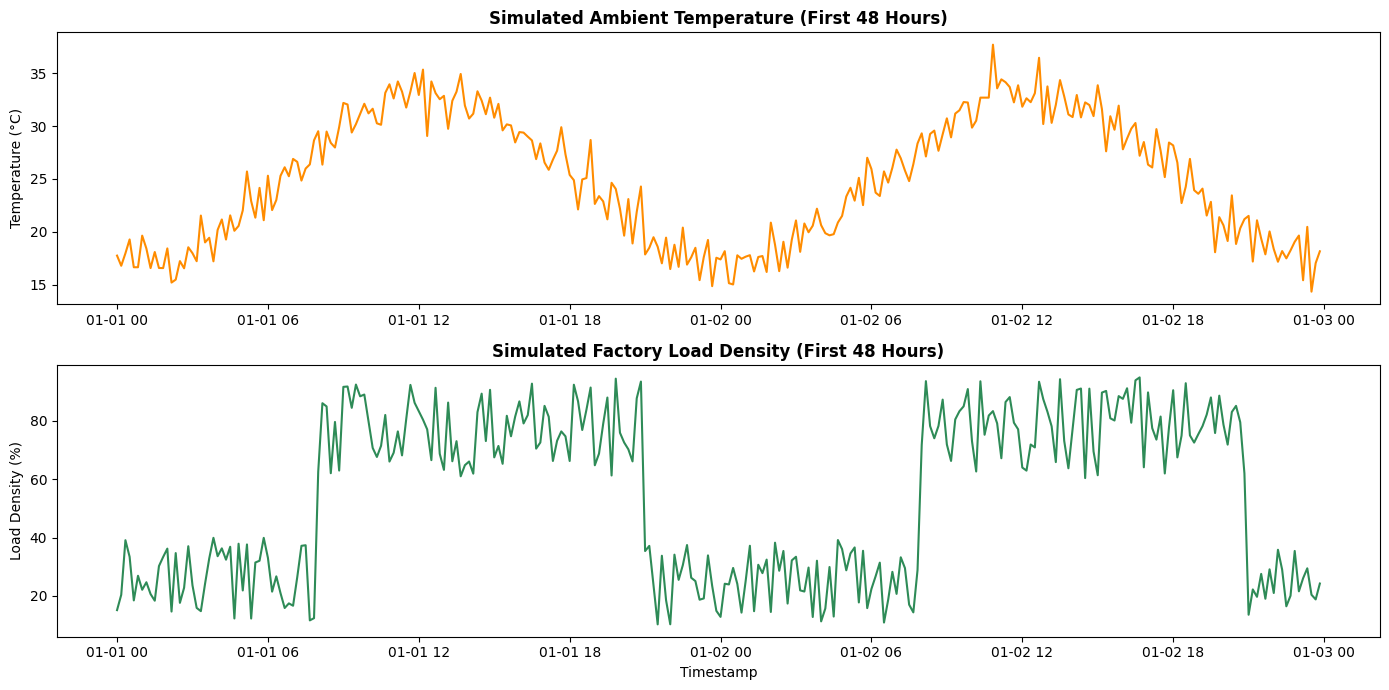

✅ Saved → reports/external_context_patterns.png


In [5]:
# ── CELL 5: Visualize External Context Patterns ──────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
 
sample = df.iloc[:288]  # first 48 hours (288 readings at 10-min intervals)
 
axes[0].plot(sample['timestamp'], sample['ambient_temperature_C'], color='darkorange')
axes[0].set_title('Simulated Ambient Temperature (First 48 Hours)', fontweight='bold')
axes[0].set_ylabel('Temperature (°C)')
 
axes[1].plot(sample['timestamp'], sample['factory_load_density'], color='seagreen')
axes[1].set_title('Simulated Factory Load Density (First 48 Hours)', fontweight='bold')
axes[1].set_ylabel('Load Density (%)')
axes[1].set_xlabel('Timestamp')
 
plt.tight_layout()
plt.savefig('../reports/external_context_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → reports/external_context_patterns.png")

In [6]:
# ── CELL 6: Fuse Internal + External Data ────────────────
# This is the core Week 2 task: merging internal sensor data
# with external context, matched on timestamp.
# Since both are already in the same dataframe (same row = same timestamp),
# the "merge" is already aligned — this confirms the fusion is correct.
 
print("✅ Contextual Data Fusion complete")
print(f"   Internal sensor columns : 5 (temperature, speed, torque, tool wear, process temp)")
print(f"   External context columns: 2 (ambient_temperature_C, factory_load_density)")
print(f"   Fusion key               : timestamp")
print(f"   Final dataset shape      : {df.shape}")
 
# Quick sanity check — no missing values introduced by fusion
print(f"\nMissing values after fusion: {df[['ambient_temperature_C', 'factory_load_density']].isnull().sum().sum()}")

✅ Contextual Data Fusion complete
   Internal sensor columns : 5 (temperature, speed, torque, tool wear, process temp)
   External context columns: 2 (ambient_temperature_C, factory_load_density)
   Fusion key               : timestamp
   Final dataset shape      : (10000, 32)

Missing values after fusion: 0


In [7]:
# ── CELL 7: Create Contextual Interaction Features ───────
# These combine internal + external signals — capturing the idea
# that a machine under high load AND high ambient heat is more likely to fail
 
df['temp_gap'] = df['Process temperature [K]'] - (df['ambient_temperature_C'] + 273.15)
# ^ difference between machine's internal process temp and outside air temp (in Kelvin)
 
df['load_torque_interaction'] = df['factory_load_density'] * df['Torque [Nm]']
# ^ captures combined mechanical + operational stress
 
df['heat_stress_index'] = df['ambient_temperature_C'] * df['Tool wear [min]'] / 100
# ^ approximates how heat + tool wear together accelerate degradation
 
context_features = ['ambient_temperature_C', 'factory_load_density',
                     'temp_gap', 'load_torque_interaction', 'heat_stress_index']
 
print("✅ Contextual interaction features created:")
for f in context_features:
    print(f"   {f}")

✅ Contextual interaction features created:
   ambient_temperature_C
   factory_load_density
   temp_gap
   load_torque_interaction
   heat_stress_index


In [9]:
# ── CELL 8: Ablation Study Setup ─────────────────────────
# Ablation study = train the SAME model twice:
#   1) using ONLY internal sensor features  (baseline)
#   2) using internal + external features   (enriched)
# Then compare Macro F1 scores to PROVE external data helps.
 
internal_features = [
    'Air temperature [K]', 'Process temperature [K]',
    'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]'
]
 
rolling_features = [c for c in df.columns if 'roll' in c]
 
baseline_features = internal_features + rolling_features
enriched_features  = baseline_features + context_features
 
target = 'Machine failure'
 
print(f"Baseline feature count  (internal only)        : {len(baseline_features)}")
print(f"Enriched feature count  (internal + external)   : {len(enriched_features)}")

Baseline feature count  (internal only)        : 20
Enriched feature count  (internal + external)   : 25


In [ ]:
# ── CELL 9: Train/Test Split ────────────────────────────
# Stratify ensures both train and test sets keep the same failure ratio
X_baseline = df[baseline_features]
X_enriched = df[enriched_features]
y = df[target]
 
X_train_base, X_test_base, y_train, y_test = train_test_split(
    X_baseline, y, test_size=0.2, random_state=42, stratify=y
)
 
X_train_enr, X_test_enr, _, _ = train_test_split(
    X_enriched, y, test_size=0.2, random_state=42, stratify=y
)
 
print(f"✅ Train/Test split complete")
print(f"   Train size : {X_train_base.shape[0]}")
print(f"   Test size  : {X_test_base.shape[0]}")
print(f"   Train failure rate : {y_train.mean()*100:.2f}%")
print(f"   Test failure rate  : {y_test.mean()*100:.2f}%")